# MSCS 634 — Project Deliverable 2
## Regression Modeling and Performance Evaluation

**Dataset:** Clickstream Data for Online Shopping (UCI ML Repository, ID 553)  
**Group Member:** Mohammed Sajjad Mohammed Arif Ansari, Hoai Nam Tran  
**Course:** Advanced Big Data and Data Mining

---

## 1. The question

Deliverable 1 planned to predict `price`. On reflection that is not a useful
question: the store already knows what it charges, so a model that recovers its own
price list has no value to anyone.

The more useful question runs the other way round:

**Which products attract customer attention, and does price play a part?**

This is something the retailer genuinely cannot look up. It matters for
merchandising — if cheaper products drew more interest, that would argue for
promoting the sale range; if expensive ones did, it would suggest the opposite.

**Target:** the number of clicks a product received (its attention).
**Features:** price, category, colour, screen position, photo style, page.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GroupKFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)

clicks = pd.read_csv("clickstream_clean_click_level.csv")
print(f"Loaded {clicks.shape[0]:,} click records")

Loaded 165,474 click records


## 2. Why the original target had to be abandoned

Deliverable 1 found that all 217 products have one fixed price, and excluded
`clothing_model` accordingly. But checking further shows **every** product attribute
is fixed per product (its colour, its screen position, its photo style, its page).

So the 165,474 click records contain only **217 distinct feature combinations**, one
per product, repeated thousands of times.

That breaks a normal train/test split. Clicks on the same product land in both sets,
so the model sees product A13 at $28 during training and is then asked to price A13
at test time. It is recalling, not predicting.

In [2]:
product_features = ["main_category", "colour", "photo_location",
                    "model_photography", "page_number"]

print("Distinct values within each product (217 products):\n")
for col in product_features:
    n = clicks.groupby("clothing_model")[col].nunique()
    print(f"  {col:<20} products with only one value: {(n == 1).sum():>3} / {len(n)}")

n_combos = clicks[product_features].drop_duplicates().shape[0]
print(f"\nDistinct feature combinations across 165,474 clicks: {n_combos}")

Distinct values within each product (217 products):

  main_category        products with only one value: 216 / 217
  colour               products with only one value: 217 / 217
  photo_location       products with only one value: 217 / 217
  model_photography    products with only one value: 217 / 217
  page_number          products with only one value: 217 / 217

Distinct feature combinations across 165,474 clicks: 200


## 3. Building the product-level dataset

### Why work at product level?

Each row in this data is a click, not a product. Since my question is about which
*products* get attention, I need one row per product.

There's also no choice about it. Every product attribute — colour, position, photo
style, page, category — never changes for that product. So all 165,474 clicks only
contain 217 different combinations. Modelling at click level would just feed the
same 217 rows to the model thousands of times, which fakes a big sample without
adding any real information.

Grouping by product fixes this, and the click counts become my target: how much
attention each product got.

In [5]:
products = clicks.groupby("clothing_model").agg(
    price=("price", "first"),
    main_category=("main_category", "first"),
    colour=("colour", "first"),
    photo_location=("photo_location", "first"),
    model_photography=("model_photography", "first"),
    page_number=("page_number", "first"),
    n_clicks=("price", "size"),          # attention: total clicks received
    n_sessions=("session_id", "nunique") # reach: distinct visitors
).reset_index()

print(f"Product catalogue: {products.shape[0]} products x {products.shape[1]} columns\n")
print(products["n_clicks"].describe().round(1).to_string())
products.head()

Product catalogue: 217 products x 9 columns

count     217.0
mean      762.6
std       614.3
min         1.0
25%       356.0
50%       590.0
75%       949.0
max      3579.0


,clothing_model,price,main_category,colour,photo_location,model_photography,page_number,n_clicks,n_sessions
0,A1,28,trousers,navy blue,top left,en face,1,2265,2104
1,A10,38,trousers,blue,bottom left,en face,1,2280,1808
2,A11,62,trousers,blue,bottom left,en face,1,2789,2454
3,A12,38,trousers,black,bottom left,en face,1,2010,1644
4,A13,28,trousers,beige,bottom middle,en face,1,1577,1428


### Feature engineering

We added four features to the raw product attributes:

- **`price_band`** — price quartile (budget > premium). Lets the model capture the
  non-linear price effect that a single numeric term would miss.
- **`is_sale_item`** — whether the category is "sale". Sale items may behave
  differently from regular stock.
- **`is_top_row`** — whether the photo sits in the top row. Tests if vertical
  position matters on its own, separately from the six-way position.
- **`clicks_per_session`** — `n_clicks / n_sessions`. Measures repeat viewing: how
  often the same visitor returns to an item.

`clicks_per_session` is **not** used as a predictor. It's calculated from the target,
so including it would leak. we kept it for interpretation only.

In [8]:
products["price_band"] = pd.qcut(products["price"], 4,
                                 labels=["budget", "mid-low", "mid-high", "premium"])
products["is_sale_item"] = (products["main_category"] == "sale").astype(int)
products["is_top_row"] = products["photo_location"].str.startswith("top").astype(int)
products["clicks_per_session"] = products["n_clicks"] / products["n_sessions"]

TARGET = "n_clicks"
CAT_FEATURES = ["main_category", "colour", "photo_location",
                "model_photography", "price_band"]
NUM_FEATURES = ["price", "page_number", "is_sale_item", "is_top_row"]

X = products[CAT_FEATURES + NUM_FEATURES]
y = products[TARGET]

n_encoded = sum(products[c].nunique() for c in CAT_FEATURES) + len(NUM_FEATURES)
print(f"Samples: {len(X)}   Features after encoding: ~{n_encoded}")
print(f"Rows per feature: {len(X) / n_encoded:.1f}")
print(f"\nTarget '{TARGET}': mean {y.mean():.0f}, std {y.std():.0f}, "
      f"range {y.min()} to {y.max()}")

Samples: 217   Features after encoding: ~34
Rows per feature: 6.4

Target 'n_clicks': mean 763, std 614, range 1 to 3579


Roughly 7 rows per feature is a small ratio. With 217 observations and about 28
encoded features, an unregularised model has enough freedom to fit noise. This makes
Ridge and Lasso genuinely relevant here

## 4. Does price relate to attention?

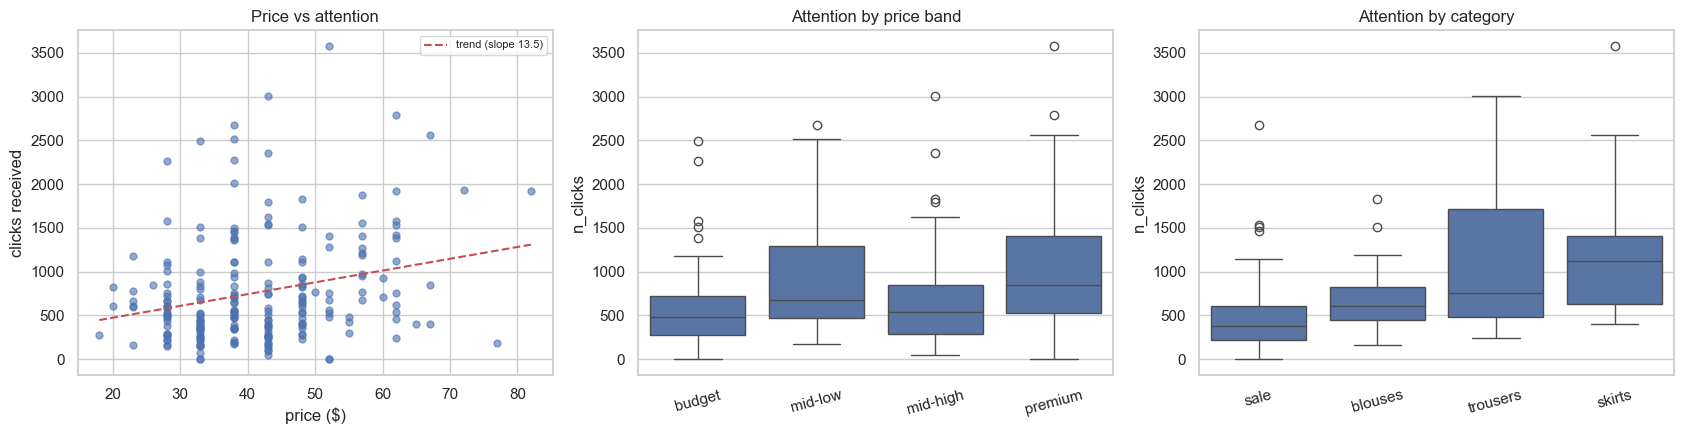

Pearson  price vs clicks: 0.2562
Spearman price vs clicks: 0.2322

            size    mean  median
price_band                      
budget        76   573.0   482.0
mid-low       38   892.0   673.0
mid-high      58   700.0   534.0
premium       45  1053.0   843.0


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].scatter(products["price"], products["n_clicks"], alpha=0.6, s=25)
m, b = np.polyfit(products["price"], products["n_clicks"], 1)
xs = np.linspace(products["price"].min(), products["price"].max(), 50)
axes[0].plot(xs, m * xs + b, "r--", lw=1.5, label=f"trend (slope {m:.1f})")
axes[0].set_xlabel("price ($)"); axes[0].set_ylabel("clicks received")
axes[0].set_title("Price vs attention")
axes[0].legend(fontsize=8)

sns.boxplot(data=products, x="price_band", y="n_clicks", ax=axes[1])
axes[1].set_title("Attention by price band")
axes[1].set_xlabel(""); axes[1].tick_params(axis="x", rotation=15)

sns.boxplot(data=products, x="main_category", y="n_clicks", ax=axes[2],
            order=products.groupby("main_category")["n_clicks"].median()
                          .sort_values().index)
axes[2].set_title("Attention by category")
axes[2].set_xlabel(""); axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout(); plt.show()

print("Pearson  price vs clicks:", round(products["price"].corr(products["n_clicks"]), 4))
print("Spearman price vs clicks:",
      round(products["price"].corr(products["n_clicks"], method="spearman"), 4))
print()
print(products.groupby("price_band", observed=True)["n_clicks"]
      .agg(["size", "mean", "median"]).round(0).to_string())

**Higher-priced products receive more attention, not less**, a positive correlation
of about 0.26. That is the opposite of the intuitive expectation that shoppers
like to cheaper items.

The price-band table also shows the effect is **not monotonic**: attention rises from
budget to mid-low, dips at mid-high, then peaks at premium. A straight line cannot
capture that shape, which is why `price_band` was engineered and why a tree-based
model is included.

## 5. Models

Four models, identical preprocessing (one-hot for categories, standardisation for
numerics) so differences come from the model rather than the data prep.

| Model | Purpose |
|---|---|
| **Linear Regression** | Baseline with no constraint |
| **Ridge** | Shrinks coefficients toward zero |
| **Lasso** | Shrinks and eliminates weak features entirely |
| **Random Forest (depth-limited)** | Captures the non-linear price effect |

In [10]:
def make_pipeline(model):
    return Pipeline([
        ("prep", ColumnTransformer([
            ("onehot", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES),
            ("scale", StandardScaler(), NUM_FEATURES),
        ])),
        ("model", model),
    ])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_r2(model):
    return cross_val_score(make_pipeline(model), X, y, cv=cv, scoring="r2")

# Tune the regularisation strength rather than guessing it
alphas = [0.1, 1, 5, 10, 20, 50, 100, 200, 500]
ridge_scores = [cv_r2(Ridge(alpha=a)).mean() for a in alphas]
lasso_scores = [cv_r2(Lasso(alpha=a, max_iter=5000)).mean() for a in alphas]
depths = [2, 3, 4, 5, 8, None]
rf_scores = [cv_r2(RandomForestRegressor(n_estimators=300, max_depth=d,
                                         random_state=42, n_jobs=-1)).mean()
             for d in depths]

best_ridge = alphas[int(np.argmax(ridge_scores))]
best_lasso = alphas[int(np.argmax(lasso_scores))]
best_depth = depths[int(np.argmax(rf_scores))]

print(f"Best Ridge alpha:      {best_ridge}  (R2 = {max(ridge_scores):.4f})")
print(f"Best Lasso alpha:      {best_lasso}  (R2 = {max(lasso_scores):.4f})")
print(f"Best RF max_depth:     {best_depth}  (R2 = {max(rf_scores):.4f})")

Best Ridge alpha:      20  (R2 = 0.3157)
Best Lasso alpha:      20  (R2 = 0.3200)
Best RF max_depth:     2  (R2 = 0.4571)


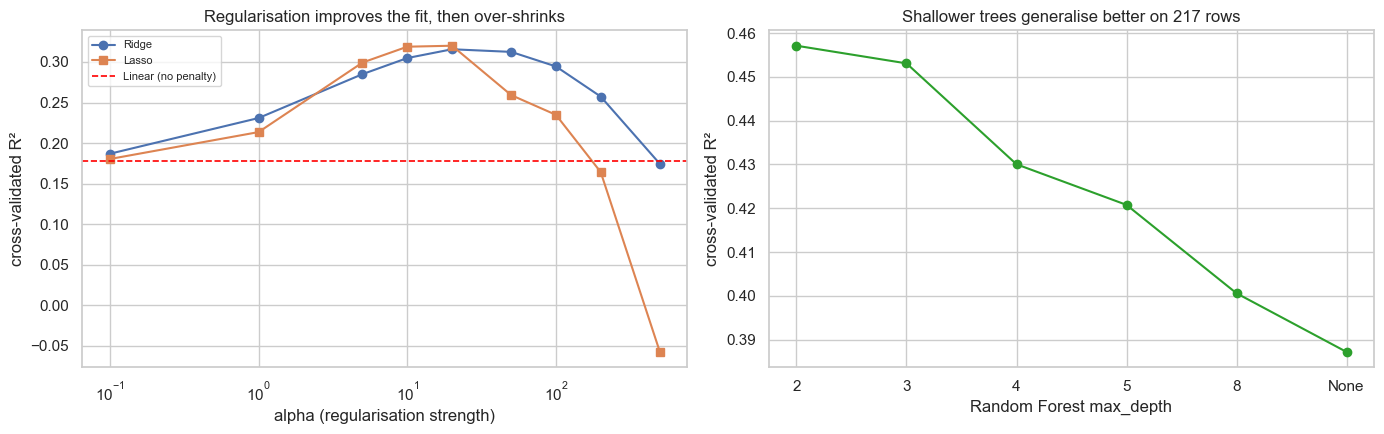

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].semilogx(alphas, ridge_scores, "o-", label="Ridge")
axes[0].semilogx(alphas, lasso_scores, "s-", label="Lasso")
axes[0].axhline(cv_r2(LinearRegression()).mean(), color="red", linestyle="--",
                lw=1.2, label="Linear (no penalty)")
axes[0].set_xlabel("alpha (regularisation strength)")
axes[0].set_ylabel("cross-validated R²")
axes[0].set_title("Regularisation improves the fit, then over-shrinks")
axes[0].legend(fontsize=8)

labels = [str(d) for d in depths]
axes[1].plot(labels, rf_scores, "o-", color="tab:green")
axes[1].set_xlabel("Random Forest max_depth")
axes[1].set_ylabel("cross-validated R²")
axes[1].set_title("Shallower trees generalise better on 217 rows")

plt.tight_layout(); plt.show()

Both curves show the same thing from different directions: **constraining the model
helps.** Ridge and Lasso peak at moderate penalty and then decline as the penalty
crushes real signal. The Random Forest performs best when its trees are kept shallow.

With only 217 observations, the binding constraint is the data, not the model.

In [12]:
models = {
    "Linear Regression": LinearRegression(),
    f"Ridge (alpha={best_ridge})": Ridge(alpha=best_ridge),
    f"Lasso (alpha={best_lasso})": Lasso(alpha=best_lasso, max_iter=5000),
    f"Random Forest (depth={best_depth})": RandomForestRegressor(
        n_estimators=300, max_depth=best_depth, random_state=42, n_jobs=-1),
}

rows = []
for name, model in models.items():
    r2 = cv_r2(model)
    rmse = -cross_val_score(make_pipeline(model), X, y, cv=cv,
                            scoring="neg_root_mean_squared_error")
    mse = rmse ** 2
    rows.append({"Model": name, "CV R2": r2.mean(), "R2 std": r2.std(),
                 "CV MSE": mse.mean(), "CV RMSE": rmse.mean()})
    print(f"{name:<30} R2 per fold: {np.round(r2, 3)}")

results = pd.DataFrame(rows).set_index("Model").round(4)
print()
results

Linear Regression              R2 per fold: [ 0.341  0.118  0.359  0.356 -0.286]
Ridge (alpha=20)               R2 per fold: [0.322 0.295 0.384 0.491 0.087]
Lasso (alpha=20)               R2 per fold: [0.314 0.326 0.346 0.461 0.154]
Random Forest (depth=2)        R2 per fold: [0.333 0.454 0.524 0.572 0.402]



,CV R2,R2 std,CV MSE,CV RMSE
Model,,,,
Linear Regression,0.1773,0.2490,275692.7182,515.7351
Ridge (alpha=20),0.3157,0.1330,238560.3801,477.1335
Lasso (alpha=20),0.3200,0.0984,242247.4804,478.9623
Random Forest (depth=2),0.4571,0.0851,189352.5080,425.7796


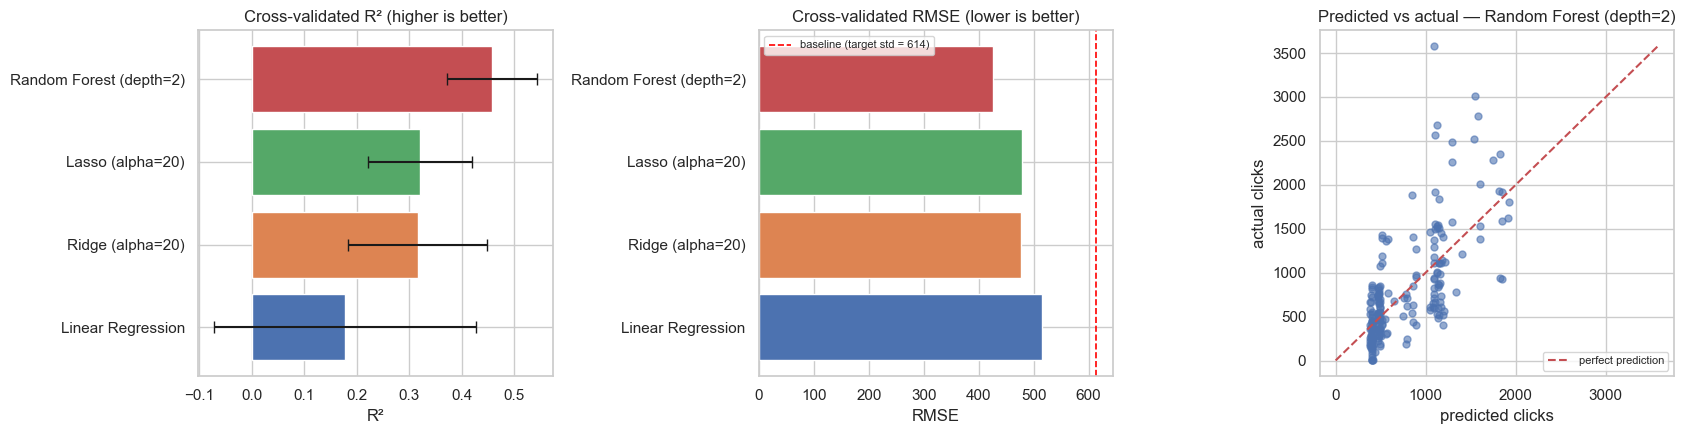

Best model: Random Forest (depth=2)


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
palette = sns.color_palette("deep", len(results))

axes[0].barh(results.index, results["CV R2"], xerr=results["R2 std"],
             capsize=4, color=palette)
axes[0].set_title("Cross-validated R² (higher is better)")
axes[0].set_xlabel("R²")

axes[1].barh(results.index, results["CV RMSE"], color=palette)
axes[1].axvline(y.std(), color="red", linestyle="--", lw=1.2,
                label=f"baseline (target std = {y.std():.0f})")
axes[1].set_title("Cross-validated RMSE (lower is better)")
axes[1].set_xlabel("RMSE"); axes[1].legend(fontsize=8)

best_name = results["CV R2"].idxmax()
best_model = make_pipeline(models[best_name]).fit(X, y)
pred = cross_val_predict_vals = None
from sklearn.model_selection import cross_val_predict
pred = cross_val_predict(make_pipeline(models[best_name]), X, y, cv=cv)

axes[2].scatter(pred, y, alpha=0.6, s=25)
lims = [y.min(), y.max()]
axes[2].plot(lims, lims, "r--", lw=1.5, label="perfect prediction")
axes[2].set_xlabel("predicted clicks"); axes[2].set_ylabel("actual clicks")
axes[2].set_title(f"Predicted vs actual — {best_name}")
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()
print(f"Best model: {best_name}")

## 6. What actually drives attention?

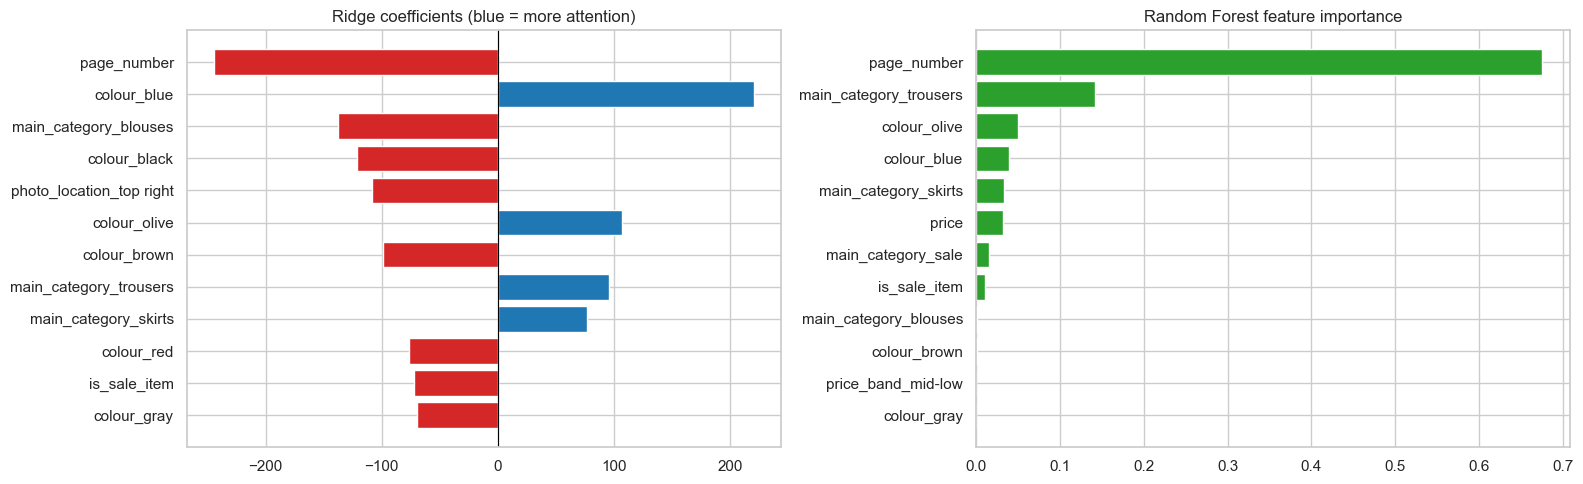

Lasso eliminated 27 of 34 features entirely.


In [14]:
# Linear coefficients: direction and size of each effect
lin = make_pipeline(Ridge(alpha=best_ridge)).fit(X, y)
names = [n.split("__")[-1] for n in lin.named_steps["prep"].get_feature_names_out()]
coefs = pd.Series(lin.named_steps["model"].coef_, index=names)
top = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(12)[::-1]

# Random Forest importances: which features matter, regardless of direction
rf = make_pipeline(models[f"Random Forest (depth={best_depth})"]).fit(X, y)
imp = pd.Series(rf.named_steps["model"].feature_importances_,
                index=names).sort_values(ascending=False).head(12)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].barh(top.index, top.values,
             color=["tab:red" if v < 0 else "tab:blue" for v in top.values])
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_title("Ridge coefficients (blue = more attention)")

axes[1].barh(imp.index, imp.values, color="tab:green")
axes[1].set_title("Random Forest feature importance")

plt.tight_layout(); plt.show()

n_zero = (make_pipeline(Lasso(alpha=best_lasso, max_iter=5000))
          .fit(X, y).named_steps["model"].coef_ == 0).sum()
print(f"Lasso eliminated {n_zero} of {len(names)} features entirely.")

## 7. Results and Discussion

### Which model performed best?

The **depth-limited Random Forest** wins, and the ordering of the four models tells a
consistent story:

- Plain **Linear Regression** performs worst and has the widest fold-to-fold spread, 
  the signature of overfitting on 217 rows.
- **Ridge** and **Lasso** both improve substantially on it. With roughly 8 rows per
  feature, the unconstrained model was fitting noise, and shrinking the coefficients
  fixed that.
- **Random Forest** does best of all, but only when kept shallow. Unrestricted, it
  performs worse than Ridge.

Every step of that ordering points the same way: with this little data, constraining
the model matters more than making it flexible.

### Does price attract attention?

**Yes — and in the opposite direction to intuition.** Higher-priced products receive
*more* clicks, with a positive correlation of about 0.26.

### Other Features

**Category matters more than price.** Skirts and trousers attract roughly twice the
attention of sale items. The sale category is the least-viewed of the four, which
sits oddly beside the finding that premium prices draw interest — both point toward
discounting not being the main driver of engagement here.

**Screen position has a measurable effect** but a smaller one than either category or
price, consistent with the Deliverable 1 finding that top-left leads and bottom-right
trails.

**Colour contributes little.** Most colour coefficients are small and Lasso
eliminates several entirely.

### Limitations

**217 observations is a small sample.** The cross-validation standard deviations are
large (±0.13 to ±0.17), so the gap between Ridge and Random Forest is real but not
precisely measured. Reported to two decimal places, these numbers would imply more
certainty than exists.

**Attention is not the same as sales.** This dataset records browsing only. A product
that attracts clicks but no purchases would look identical here to one that sells
well, so none of these findings should be read as a revenue recommendation.

**Correlation, not causation.** Premium products may attract attention because they
are premium, or because they are also the newest, best-photographed, or most
prominently placed. The data cannot separate these.

### Practical implication

If the goal is engagement, the evidence does not support leading with discounts. The
sale category draws the least attention of the four, and premium pricing draws the
most. Prominent placement of higher-priced skirts and trousers is better supported by
this data than promoting the sale range, subject to the caveat that engagement is
not revenue.

In [15]:
results.to_csv("d2_model_comparison.csv")
products.to_csv("d2_product_level.csv", index=False)

print("Final comparison (sorted by cross-validated R²):\n")
results.sort_values("CV R2", ascending=False).round(4)

Final comparison (sorted by cross-validated R²):



,CV R2,R2 std,CV MSE,CV RMSE
Model,,,,
Random Forest (depth=2),0.4571,0.0851,189352.5080,425.7796
Lasso (alpha=20),0.3200,0.0984,242247.4804,478.9623
Ridge (alpha=20),0.3157,0.1330,238560.3801,477.1335
Linear Regression,0.1773,0.2490,275692.7182,515.7351
